In [ ]:
%pip install tensorflow
%pip install lets-plot

# Exploration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lets_plot import *
#
#%%
#Model testing first
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np
bikes = pd.read_csv("https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv")
bikes.tail()


## It is important to be aware of every kind of events (including political) because in those days were the maximum amount of uses of bikes

In [ ]:
bikes.describe()

In [ ]:
bikes[bikes['casual']>1000]

In [ ]:
bikes[(bikes['registered']>1500) | (bikes['casual'] > 1500)].groupby(['day','month','year']).agg(total_casual = ('casual','sum'), total_registered = ('registered','sum'))

In [ ]:
bikes[(bikes['casual'] > 1500) | bikes(['registered'] > 1500)]

In [ ]:
bikes["datetime"] = pd.to_datetime(bikes["dteday"])
bikes["month"] = bikes["datetime"].dt.month
bikes['day'] = bikes['datetime'].dt.month
bikes["day_of_week"] = bikes["datetime"].dt.dayofweek
bikes["year"] = bikes["datetime"].dt.year
bikes = bikes.drop(columns = ['dteday'])
bikes['total'] = bikes['casual'] + bikes['registered']

In [ ]:
bikes[(bikes['year'] == 2018) & (bikes['season'] == 3)].head(20)

## What is the peak hour?
between 6am and 8am, and between 4pm and 6pm. However in weekends the peak is not as high but people rides between 8am and 8pm.

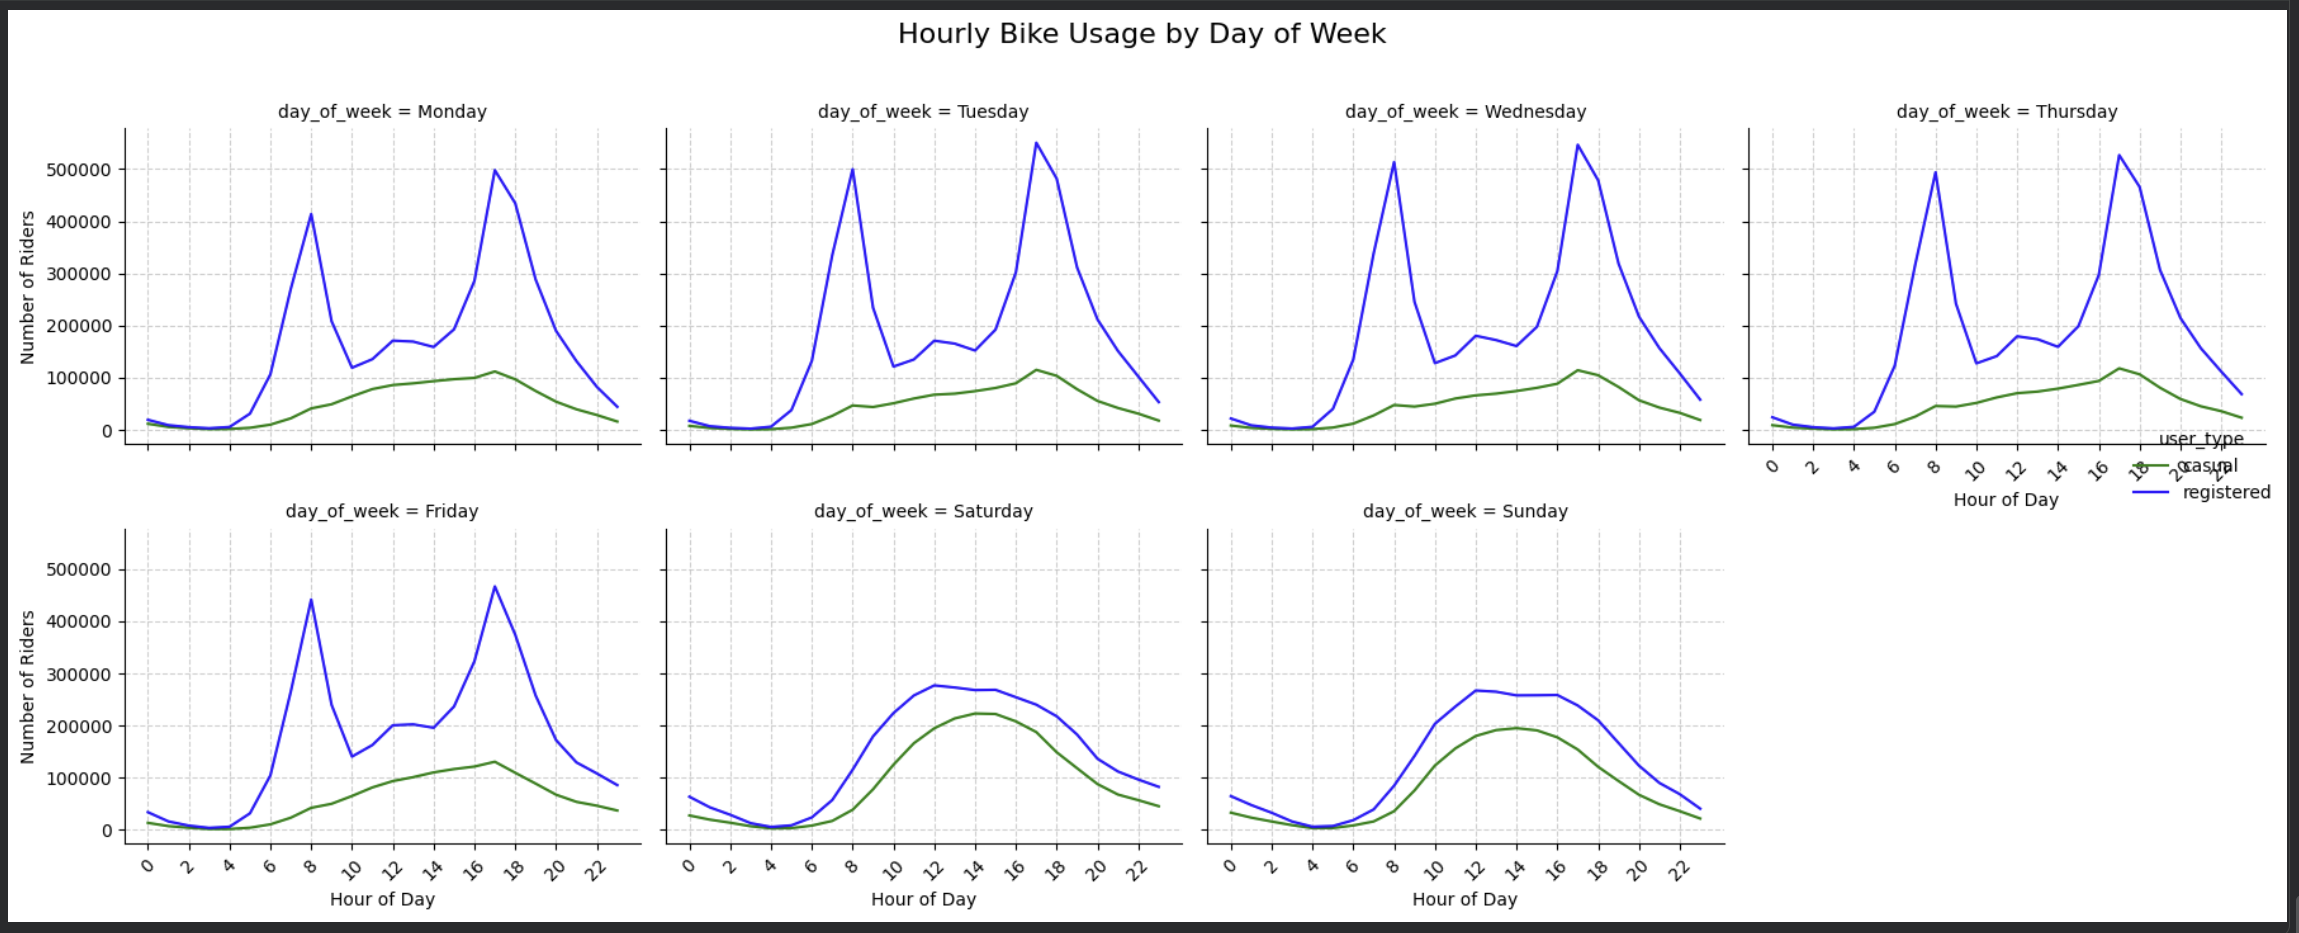

## What % of total daily rents this windows happens?

Aprox 69% of the daily rents happens in the windows of 6-10am and 2-8pm.

On weekdays,
The morning window represents 23%
The afternoon window represents 46%

On weekends,
The total rents is distributed more consistently throughout the day. No peak hours detected. just consistence between 6am and 8pm with more density on 12pm and 3pm




In [ ]:
import pandas as pd
import numpy as np

# Define peak hour windows
# 6-8 AM (hours 6, 7)
peak_morning_start = 6
peak_morning_end = 10 # Exclusive, so includes hour 7

# 2-8 PM (hours 14, 15, 16, 17, 18, 19)
peak_afternoon_start = 14
peak_afternoon_end = 20 # Exclusive, so includes hour 19

# Calculate total daily rentals
daily_rentals = bikes.groupby(['year', 'month', 'day', 'day_of_week'])['total'].sum().reset_index()
daily_rentals = daily_rentals.rename(columns={'total': 'daily_total_rentals'})

# Calculate rentals during peak morning hours
peak_morning_rentals = bikes[
    (bikes['hr'] >= peak_morning_start) & (bikes['hr'] < peak_morning_end)
].groupby(['year', 'month', 'day', 'day_of_week'])['total'].sum().reset_index()
peak_morning_rentals = peak_morning_rentals.rename(columns={'total': 'peak_morning_rentals'})

# Calculate rentals during peak afternoon hours
peak_afternoon_rentals = bikes[
    (bikes['hr'] >= peak_afternoon_start) & (bikes['hr'] < peak_afternoon_end)
].groupby(['year', 'month', 'day', 'day_of_week'])['total'].sum().reset_index()
peak_afternoon_rentals = peak_afternoon_rentals.rename(columns={'total': 'peak_afternoon_rentals'})

# Merge all dataframes
merged_rentals = pd.merge(daily_rentals, peak_morning_rentals, on=['year', 'month', 'day', 'day_of_week'], how='left')
merged_rentals = pd.merge(merged_rentals, peak_afternoon_rentals, on=['year', 'month', 'day', 'day_of_week'], how='left')

# Fill NaN values (days without rentals in a specific peak window) with 0
merged_rentals['peak_morning_rentals'] = merged_rentals['peak_morning_rentals'].fillna(0)
merged_rentals['peak_afternoon_rentals'] = merged_rentals['peak_afternoon_rentals'].fillna(0)

# Calculate total peak hour rentals
merged_rentals['total_peak_rentals'] = merged_rentals['peak_morning_rentals'] + merged_rentals['peak_afternoon_rentals']

# Calculate percentage of total daily rentals during peak hours
# Handle potential division by zero if daily_total_rentals is 0
merged_rentals['peak_percentage'] = (
    merged_rentals['total_peak_rentals'] / merged_rentals['daily_total_rentals']
) * 100
merged_rentals['peak_percentage'] = merged_rentals['peak_percentage'].replace([np.inf, -np.inf], 0).fillna(0)


# Calculate the average peak percentage by day of the week
peak_hour_percentages = merged_rentals.groupby('day_of_week')['peak_percentage'].mean().reset_index()

# Map day_of_week to names for better readability
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
peak_hour_percentages['day_of_week_name'] = peak_hour_percentages['day_of_week'].map(day_names)

print("Average percentage of daily total bike rentals during peak hours (6-8 AM and 2-8 PM) by day of the week:")
display(peak_hour_percentages)

In [ ]:
((merged_rentals[merged_rentals['day_of_week']<5]['peak_morning_rentals'] / merged_rentals[merged_rentals['day_of_week']<5]['daily_total_rentals'])*100).mean()

In [ ]:
((merged_rentals[merged_rentals['day_of_week']<5]['peak_afternoon_rentals'] / merged_rentals[merged_rentals['day_of_week']<5]['daily_total_rentals'])*100).mean()

In [ ]:
merged_rentals[merged_rentals['day_of_week']<5]['peak_percentage'].mean()

In [ ]:
((merged_rentals[merged_rentals['day_of_week']>=5]['peak_morning_rentals'] / merged_rentals[merged_rentals['day_of_week']>=5]['daily_total_rentals'])*100).mean()

In [ ]:
((merged_rentals[merged_rentals['day_of_week']>=5]['peak_afternoon_rentals'] / merged_rentals[merged_rentals['day_of_week']>=5]['daily_total_rentals'])*100).mean()

In [ ]:
merged_rentals[merged_rentals['day_of_week']>=5]['peak_percentage'].mean()

In [ ]:
from lets_plot import *

plot_peak_percentage = (
    ggplot(peak_hour_percentages, aes(x='day_of_week_name', y='peak_percentage', fill='day_of_week_name'))
    + geom_bar(stat='identity')
    + labs(
        title='Average Percentage of Daily Rentals during Peak Hours by Day of the Week',
        x='Day of the Week',
        y='Average Peak Percentage (%)',
        fill='Day of the Week'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(plot_peak_percentage)

In [ ]:
import pandas as pd
import numpy as np
from lets_plot import *

# Ensure 'total' column exists (if not already created)
if 'total' not in bikes.columns:
    bikes['total'] = bikes['casual'] + bikes['registered']

# Create a unique day identifier for grouping
bikes['day_identifier'] = bikes['year'].astype(str) + '-' + bikes['month'].astype(str).str.zfill(2) + '-' + bikes['day'].astype(str).str.zfill(2)

# Calculate total daily rentals
daily_totals = bikes.groupby('day_identifier')['total'].sum().reset_index()
daily_totals.rename(columns={'total': 'daily_total_rentals'}, inplace=True)

# Calculate hourly rentals for casual, registered, and total
hourly_rentals_detailed = bikes.groupby(['day_identifier', 'day_of_week', 'hr'])[['casual', 'registered', 'total']].sum().reset_index()

# Merge with daily totals
hourly_proportions_detailed = pd.merge(hourly_rentals_detailed, daily_totals, on='day_identifier', how='left')

# Calculate the proportion of hourly casual and registered rentals relative to the daily total
hourly_proportions_detailed['casual_proportion'] = hourly_proportions_detailed.apply(
    lambda row: row['casual'] / row['daily_total_rentals'] if row['daily_total_rentals'] > 0 else 0,
    axis=1
)
hourly_proportions_detailed['registered_proportion'] = hourly_proportions_detailed.apply(
    lambda row: row['registered'] / row['daily_total_rentals'] if row['daily_total_rentals'] > 0 else 0,
    axis=1
)

# Melt the detailed proportions for plotting
df_melted_proportions = hourly_proportions_detailed.melt(
    id_vars=['day_identifier', 'day_of_week', 'hr'],
    value_vars=['casual_proportion', 'registered_proportion'],
    var_name='rider_type',
    value_name='proportion'
)

# Calculate the average hourly proportion for each day of the week and rider type
average_hourly_proportions_detailed = df_melted_proportions.groupby(['day_of_week', 'hr', 'rider_type'])['proportion'].mean().reset_index()

# Map day_of_week to names for better readability and ensure correct order
day_names_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
average_hourly_proportions_detailed['day_of_week_name'] = average_hourly_proportions_detailed['day_of_week'].map(day_names_map)
average_hourly_proportions_detailed['day_of_week_name'] = pd.Categorical(average_hourly_proportions_detailed['day_of_week_name'], categories=day_names_order, ordered=True)

# Display the first few rows of the result
print("Average hourly proportions of bike rentals by day of the week and rider type:")
display(average_hourly_proportions_detailed.head())

# Create the bar grid plot
plot_hourly_proportions_detailed = (
    ggplot(average_hourly_proportions_detailed, aes(x='hr', y='proportion', color='rider_type'))
    + geom_line(size=1)
    + facet_grid(x='day_of_week_name', scales='free_x') # Create a subplot for each day of the week
    + labs(
        title='Hourly Proportion of Bike Rentals by Day of the Week and Rider Type',
        x='Hour of Day',
        y='Average Proportion of Daily Rentals',
        color='Rider Type'
    )
    + scale_x_continuous(breaks=list(range(0, 24, 4))) # Set x-axis breaks for hours
    + ggsize(1000, 300)
)

display(plot_hourly_proportions_detailed)

In [ ]:
# Calculate total daily rentals for each day
bikes['day_identifier'] = bikes['year'].astype(str) + '-' + bikes['month'].astype(str).str.zfill(2) + '-' + bikes['day'].astype(str).str.zfill(2)
daily_totals_df = bikes.groupby('day_identifier')['total'].sum().reset_index()
daily_totals_df.rename(columns={'total': 'daily_total_rentals'}, inplace=True)

# Calculate total casual and registered rentals for each day, and keep the correct day_of_week
daily_rider_totals_df = bikes.groupby('day_identifier').agg({'casual': 'sum', 'registered': 'sum', 'day_of_week': 'first'}).reset_index()

# Merge daily rider totals with daily total rentals
daily_proportions_df = pd.merge(daily_rider_totals_df, daily_totals_df, on='day_identifier')

# Calculate daily proportions
daily_proportions_df['casual_daily_proportion'] = daily_proportions_df.apply(
    lambda row: row['casual'] / row['daily_total_rentals'] if row['daily_total_rentals'] > 0 else 0,
    axis=1
)
daily_proportions_df['registered_daily_proportion'] = daily_proportions_df.apply(
    lambda row: row['registered'] / row['daily_total_rentals'] if row['daily_total_rentals'] > 0 else 0,
    axis=1
)

# Melt for easier averaging and plotting
daily_proportions_melted = daily_proportions_df.melt(
    id_vars=['day_identifier', 'day_of_week'],
    value_vars=['casual_daily_proportion', 'registered_daily_proportion'],
    var_name='rider_type',
    value_name='daily_proportion'
)

# Calculate the average daily proportion for each rider type by day of the week
average_daily_proportions_by_type = daily_proportions_melted.groupby(['day_of_week', 'rider_type'])['daily_proportion'].mean().reset_index()

# Map day_of_week to names for readability
day_names_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
average_daily_proportions_by_type['day_of_week_name'] = average_daily_proportions_by_type['day_of_week'].map(day_names_map)
average_daily_proportions_by_type

In [ ]:
average_hourly_proportions_detailed.groupby('rider_type')['proportion'].sum()

## Do weekends matter?
Yes. registered people uses to ride on weekdays, and reduces their frequency on weekends.
On the other hand, casual people uses to ride on weekends, mainly on satudays, however sundays still has a big difference in comparison to weekdays.

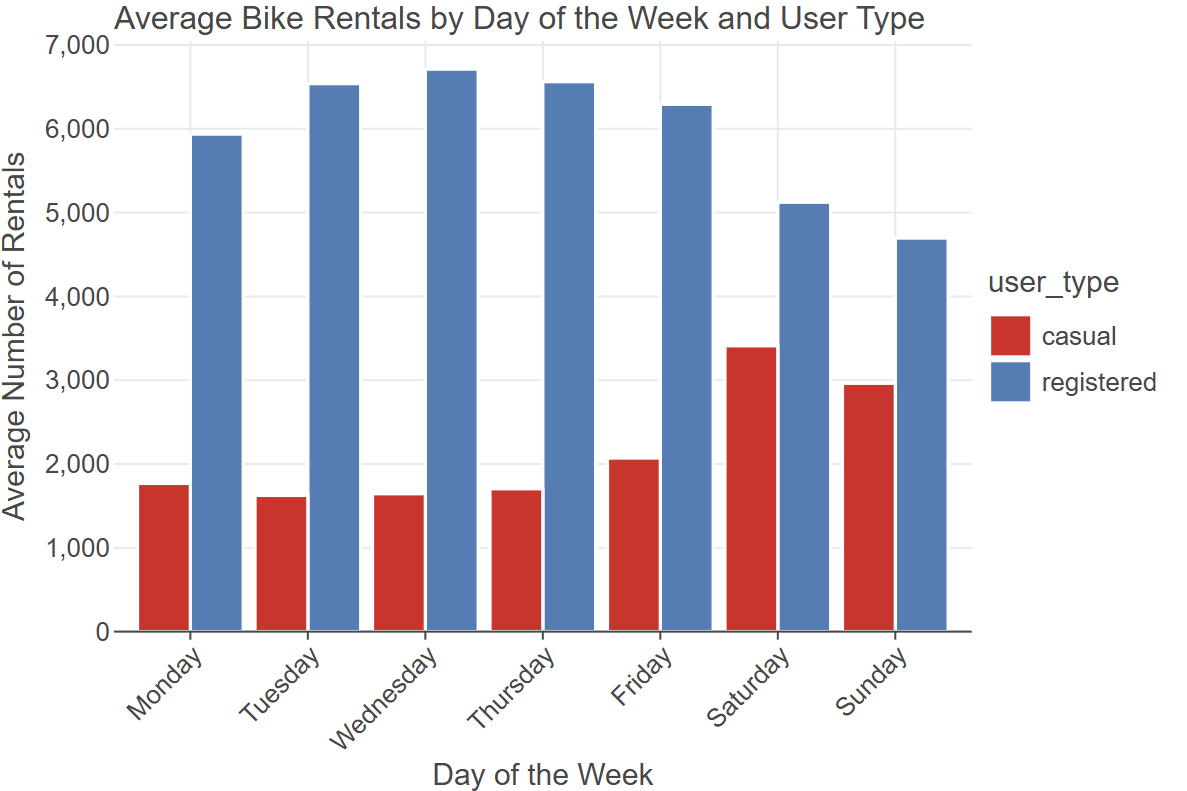

## how does the amount of bikes differ when it is holidays?
 1. The behavior of types of riders does not vary much. Registered Riders are more plausible to rent than casual ones by far, but in holidays casual ones are more often
 2. Is slightly more on weekdends, but are almost the same. Its interesting that in the middle of the week are more outliers than weekends
 3. Yes. Being ways less frequent than weekdays, holidays' distribution and total are very similay to weekdays.

In [ ]:

from lets_plot import *
import pandas as pd


# Calculate proportions
bikes['casual_proportion'] = bikes['casual'] / bikes['total']
bikes['registered_proportion'] = bikes['registered'] / bikes['total']

# Reshape data for plotting
df_proportions = bikes[['holiday', 'casual_proportion', 'registered_proportion']].melt(
    id_vars=['holiday'], var_name='rider_type', value_name='proportion'
)

# Plot proportions
plot_proportions = ggplot(df_proportions, aes(x='holiday', y='proportion', fill='rider_type')) + \
    geom_boxplot() + \
    labs(title='Rider Proportions by Holiday Status',
         x='Holiday (0: No, 1: Yes)',
         y='Proportion of Total Rides',
         fill='Rider Type')

display(plot_proportions)

In [ ]:
ggplot(bikes, aes(x = 'day_of_week', y = 'total')) + geom_boxplot()

In [ ]:
from lets_plot import *
import pandas as pd

bikes['total'] = bikes['casual'] + bikes['registered']

plot_total_by_holiday = ggplot(bikes, aes(x = 'holiday', y = 'total')) + \
    geom_boxplot() + \
    labs(title='Total Bike Rentals by Holiday Status',
         x='Holiday (0: No, 1: Yes)',
         y='Total Rides')

display(plot_total_by_holiday)

## which season is the most demanded for bike rents?
Spring and Summer are more frequent to rent bikes. However, fall has more outliers. Why?? Covid?

In [ ]:
ggplot(bikes, aes('season', 'total')) + geom_boxplot()

## how the weather affect to the bikes rents? is temperature important?
1. The distribution of both, temperature and feels_like are right-skewed. Both shows that people uses more bikes when the temperature or feels_like is close to 26-27°C and decreases when it exceeds this value. -> **It is important to normalize it.**

2. Windspeed needs normalization

3. Registered users don't care much about humitity or temperature as much as casual


In [ ]:
ggplot(bikes, aes('temp_c', 'total')) + geom_point()

In [ ]:
ggplot(bikes, aes('temp_c', 'casual')) + geom_point()

In [ ]:
ggplot(bikes, aes('temp_c', 'registered')) + geom_point()

In [ ]:
ggplot(bikes, aes('feels_like_c', 'total')) + geom_point()

In [ ]:
ggplot(bikes, aes('feels_like_c', 'casual')) + geom_point()

In [ ]:
ggplot(bikes, aes('feels_like_c', 'registered')) + geom_point()

In [ ]:
ggplot(bikes, aes('hum', 'total')) + geom_point()

In [ ]:
ggplot(bikes, aes('windspeed', 'total')) + geom_point()

## What is more important? temp or feels_like?

Feelslike is a mix of hum, windspeed and temp.

Use: TEMP + HUM + WINDSPEED OR FEELSLIKE

## Is there any interaction with the weather situation?
No. The proportion keeps being the same no matter the weathersit. The only thinG that changes is the amount. 1 > 2 > 3 >> 4

In [ ]:
from lets_plot import *
import pandas as pd

# Ensure 'total' column exists
if 'total' not in bikes.columns:
    bikes['total'] = bikes['casual'] + bikes['registered']

# Map day_of_week to names for better readability
day_names_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
bikes['day_of_week_name'] = bikes['day_of_week'].map(day_names_map)

# Map weathersit to names for better readability
weathersit_names = {1: 'Clear', 2: 'Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Snow/Rain'}
bikes['weathersit_name'] = bikes['weathersit'].map(weathersit_names)

# Melt the data to have 'casual' and 'registered' as a single column for plotting
df_melted_riders = bikes.melt(
    id_vars=['day_of_week_name', 'weathersit_name'],
    value_vars=['casual', 'registered'],
    var_name='rider_type',
    value_name='rentals'
)

# Aggregate rentals by day, weathersit, and rider type for plotting
# This ensures we're plotting sums for each category
aggregated_rentals = df_melted_riders.groupby(['day_of_week_name', 'weathersit_name', 'rider_type'])['rentals'].mean().reset_index()

# Ensure day_of_week_name is ordered correctly for plotting
day_names_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
aggregated_rentals['day_of_week_name'] = pd.Categorical(aggregated_rentals['day_of_week_name'], categories=day_names_order, ordered=True)


plot_weathersit_impact = (
    ggplot(aggregated_rentals, aes(x='day_of_week_name', y='rentals', fill='rider_type'))
    + geom_bar(stat='identity', position='dodge') # 'dodge' for side-by-side bars
    + facet_grid(x='weathersit_name', scales='free_x') # Separate plots by weather situation
    + labs(
        title='Bike Rentals by Day of Week, Rider Type, and Weather Situation',
        x='Day of the Week',
        y='Mean Rentals',
        fill='Rider Type'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
    + ggsize(1000, 600)
)

display(plot_weathersit_impact)

## Impact of Covid. Until what time it got back to normality?

between spring 2020 and Fall 2021. Internet says 2nd November. The amount of bike rents increases slightly according to the season until fall 2021, when the rents can be considered that are back in the normality.
I would be better to set exact dates.

In [ ]:
from lets_plot import *
import pandas as pd

# Ensure 'total' column exists
if 'total' not in bikes.columns:
    bikes['total'] = bikes['casual'] + bikes['registered']

# Create 'year_month' column for all data
bikes['year_month'] = bikes['year'].astype(str) + '-' + bikes['month'].astype(str).str.zfill(2)

# Aggregate total rentals by 'year_month'
timeline_data_all = bikes.groupby('year_month')['total'].sum().reset_index()

# Sort by 'year_month' to ensure correct plotting order
timeline_data_all = timeline_data_all.sort_values('year_month')

# Create custom labels for x-axis: '#month last_2_digits_of_year'
timeline_data_all['display_label'] = timeline_data_all['year_month'].apply(lambda x: f"#{x.split('-')[1]} {x.split('-')[0][-2:]}")

# Plotting the timeline for all data
timeline_plot_all = (
    ggplot(timeline_data_all, aes(x='display_label', y='total'))
    + geom_line(color='blue', size=1)
    + labs(
        title='Total Bike Rentals Over Time (All Data)',
        x='Month-Year',
        y='Total Bike Rentals'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(timeline_plot_all)

In [ ]:
bikes_winter = bikes[bikes['season'] == 1].copy()
bikes_winter['year_month'] = bikes_winter['year'].astype(str) + '-' + bikes_winter['month'].astype(str).str.zfill(2)

timeline_data_winter = bikes_winter.groupby('year_month')['total'].sum().reset_index()
timeline_data_winter = timeline_data_winter.sort_values('year_month')
timeline_data_winter['display_label'] = timeline_data_winter['year_month'].apply(lambda x: f"#{x.split('-')[1]} {x.split('-')[0][-2:]}")

timeline_plot_winter = (
    ggplot(timeline_data_winter, aes(x='display_label', y='total'))
    + geom_line(color='blue', size=1)
    + labs(
        title='Total Bike Rentals Over Time (Winter Season)',
        x='Month-Year',
        y='Total Bike Rentals'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(timeline_plot_winter)

In [ ]:
bikes_spring = bikes[bikes['season'] == 2].copy()
bikes_spring['year_month'] = bikes_spring['year'].astype(str) + '-' + bikes_spring['month'].astype(str).str.zfill(2)

timeline_data_spring = bikes_spring.groupby('year_month')['total'].sum().reset_index()
timeline_data_spring = timeline_data_spring.sort_values('year_month')
timeline_data_spring['display_label'] = timeline_data_spring['year_month'].apply(lambda x: f"#{x.split('-')[1]} {x.split('-')[0][-2:]}")

timeline_plot_spring = (
    ggplot(timeline_data_spring, aes(x='display_label', y='total'))
    + geom_line(color='orange', size=1)
    + labs(
        title='Total Bike Rentals Over Time (Spring Season)',
        x='Month-Year',
        y='Total Bike Rentals'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(timeline_plot_spring)

In [ ]:
bikes_summer = bikes[bikes['season'] == 3].copy()
bikes_summer['year_month'] = bikes_summer['year'].astype(str) + '-' + bikes_summer['month'].astype(str).str.zfill(2)

timeline_data_summer = bikes_summer.groupby('year_month')['total'].sum().reset_index()
timeline_data_summer = timeline_data_summer.sort_values('year_month')
timeline_data_summer['display_label'] = timeline_data_summer['year_month'].apply(lambda x: f"#{x.split('-')[1]} {x.split('-')[0][-2:]}")

timeline_plot_summer = (
    ggplot(timeline_data_summer, aes(x='display_label', y='total'))
    + geom_line(color='green', size=1)
    + labs(
        title='Total Bike Rentals Over Time (Summer Season)',
        x='Month-Year',
        y='Total Bike Rentals'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(timeline_plot_summer)

In [ ]:
bikes_fall = bikes[bikes['season'] == 4].copy()
bikes_fall['year_month'] = bikes_fall['year'].astype(str) + '-' + bikes_fall['month'].astype(str).str.zfill(2)

timeline_data_fall = bikes_fall.groupby('year_month')['total'].sum().reset_index()
timeline_data_fall = timeline_data_fall.sort_values('year_month')
timeline_data_fall['display_label'] = timeline_data_fall['year_month'].apply(lambda x: f"#{x.split('-')[1]} {x.split('-')[0][-2:]}")

timeline_plot_fall = (
    ggplot(timeline_data_fall, aes(x='display_label', y='total'))
    + geom_line(color='red', size=1)
    + labs(
        title='Total Bike Rentals Over Time (Fall Season)',
        x='Month-Year',
        y='Total Bike Rentals'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(timeline_plot_fall)

In [ ]:
from lets_plot import *
import pandas as pd

# Ensure 'total' column exists
if 'total' not in bikes.columns:
    bikes['total'] = bikes['casual'] + bikes['registered']

# Aggregate total rentals by year and season
yearly_seasonal_data = bikes.groupby(['year', 'season'])['total'].sum().reset_index()

# Map season numbers to names for better readability
season_names = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
yearly_seasonal_data['season_name'] = yearly_seasonal_data['season'].map(season_names)

# Plotting the stacked bar chart
plot_yearly_seasonal = ( # Renamed the plot object
    ggplot(yearly_seasonal_data, aes(x='year', y='total', fill='season_name'))
    + geom_bar(stat='identity', position = 'dodge')
    + labs(
        title='Total Bike Rentals by Year and Season',
        x='Year',
        y='Total Bike Rentals',
        fill='Season'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(plot_yearly_seasonal)

## When COVID is considered over?

 From March 2020 to October 2021

In [ ]:
baseline_periods = bikes[(bikes['year'] >= 2018) & (bikes['year'] <= 2019)].copy()
baseline_monthly_avg = baseline_periods.groupby(['year', 'month'])['total'].mean().reset_index()
post_covid_periods = bikes[(bikes['year'] >= 2020) & (bikes['year'] <= 2022)].copy()
post_covid_monthly_avg = post_covid_periods.groupby(['year', 'month'])['total'].mean().reset_index()
baseline_monthly_avg_std = baseline_monthly_avg.groupby('month')['total'].agg(['mean', 'std']).reset_index()
baseline_monthly_avg_std.columns = ['month', 'baseline_avg', 'baseline_std']

comparison_df = pd.merge(post_covid_monthly_avg, baseline_monthly_avg_std, on='month', how='left')
comparison_df['lower_bound'] = comparison_df['baseline_avg'] - comparison_df['baseline_std']
comparison_df['upper_bound'] = comparison_df['baseline_avg'] + comparison_df['baseline_std']

def check_normality(row):
    if row['total'] >= row['lower_bound'] and row['total'] <= row['upper_bound']:
        return 'Within Normal Range'
    elif row['total'] < row['lower_bound']:
        return 'Below Normal'
    else:
        return 'Above Normal'

comparison_df['normality_status'] = comparison_df.apply(check_normality, axis=1)
comparison_df['year_month'] = comparison_df['year'].astype(str) + '-' + comparison_df['month'].astype(str).str.zfill(2)


print("Comparison DataFrame with normality status (first 5 rows):")
display(comparison_df.head())

In [ ]:
normality_counts = comparison_df['normality_status'].value_counts()

print("Count of months by normality status:")
display(normality_counts)

In [ ]:
comparison_df = comparison_df.sort_values('year_month')

# Melt the DataFrame to prepare for plotting multiple lines with a single color aesthetic
comparison_df_for_plot = comparison_df.melt(
    id_vars=['year_month', 'lower_bound', 'upper_bound', 'normality_status', 'year'],
    value_vars=['total', 'baseline_avg'], # 'total' is the post_covid_avg in this df
    var_name='metric_type',
    value_name='value'
)

plot_normality = (
    ggplot(comparison_df_for_plot, aes(x='year_month', y='value', color='metric_type'))
    + geom_line(size=1)
    + geom_ribbon(aes(ymin='lower_bound', ymax='upper_bound'), fill='gray', alpha=0.3, show_legend=False) # Removed group=1
    + labs(
        title='Post-COVID Monthly Averages vs. Baseline Normality',
        x='Month-Year',
        y='Total Bike Rentals',
        color='Metric' # Legend title
    )
    + scale_color_manual(values={'total': 'blue', 'baseline_avg': 'red'}, labels={'total': 'Post-COVID Average', 'baseline_avg': 'Baseline Average'})
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(plot_normality)

In [ ]:

r2 = r2_score(y_test,predictions)
r2

¿Cuales son los limites que tiene el negocio? ¿Que es lo que le gustaria saber?

## The proportions after COVID changed? Registered keeps being the leader? what changed after COVID?

The behavior post-covid changed! More people are interested on riding bikes as hobby: The registered proportion keeps being the same, but the casual one increased -> total of more people riding bikes caused by the increment of casual riders

In [ ]:
# After covid?
import pandas as pd
import numpy as np

# Define peak hour windows
# 6-8 AM (hours 6, 7)
peak_morning_start = 6
peak_morning_end = 10 # Exclusive, so includes hour 7

# 2-8 PM (hours 14, 15, 16, 17, 18, 19)
peak_afternoon_start = 14
peak_afternoon_end = 20 # Exclusive, so includes hour 19

# Calculate total daily rentals
daily_rentals = bikes[(bikes['year'] >= 2022)].groupby(['year', 'month', 'day', 'day_of_week'])['total'].sum().reset_index()
daily_rentals = daily_rentals.rename(columns={'total': 'daily_total_rentals'})

# Calculate rentals during peak morning hours
peak_morning_rentals = bikes[
    (bikes['year'] >= 2022) & (bikes['hr'] >= peak_morning_start) & (bikes['hr'] < peak_morning_end)
].groupby(['year', 'month', 'day', 'day_of_week'])['total'].sum().reset_index()
peak_morning_rentals = peak_morning_rentals.rename(columns={'total': 'peak_morning_rentals'})

# Calculate rentals during peak afternoon hours
peak_afternoon_rentals = bikes[
    (bikes['year'] >= 2022) & (bikes['hr'] >= peak_afternoon_start) & (bikes['hr'] < peak_afternoon_end)
].groupby(['year', 'month', 'day', 'day_of_week'])['total'].sum().reset_index()
peak_afternoon_rentals = peak_afternoon_rentals.rename(columns={'total': 'peak_afternoon_rentals'})

# Merge all dataframes
merged_rentals = pd.merge(daily_rentals, peak_morning_rentals, on=['year', 'month', 'day', 'day_of_week'], how='left')
merged_rentals = pd.merge(merged_rentals, peak_afternoon_rentals, on=['year', 'month', 'day', 'day_of_week'], how='left')

# Fill NaN values (days without rentals in a specific peak window) with 0
merged_rentals['peak_morning_rentals'] = merged_rentals['peak_morning_rentals'].fillna(0)
merged_rentals['peak_afternoon_rentals'] = merged_rentals['peak_afternoon_rentals'].fillna(0)

# Calculate total peak hour rentals
merged_rentals['total_peak_rentals'] = merged_rentals['peak_morning_rentals'] + merged_rentals['peak_afternoon_rentals']

# Calculate percentage of total daily rentals during peak hours
# Handle potential division by zero if daily_total_rentals is 0
merged_rentals['peak_percentage'] = (
    merged_rentals['total_peak_rentals'] / merged_rentals['daily_total_rentals']
) * 100
merged_rentals['peak_percentage'] = merged_rentals['peak_percentage'].replace([np.inf, -np.inf], 0).fillna(0)


# Calculate the average peak percentage by day of the week
peak_hour_percentages = merged_rentals.groupby('day_of_week')['peak_percentage'].mean().reset_index()

# Map day_of_week to names for better readability
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
peak_hour_percentages['day_of_week_name'] = peak_hour_percentages['day_of_week'].map(day_names)

print("Average percentage of daily total bike rentals during peak hours (6-8 AM and 2-8 PM) by day of the week:")
display(peak_hour_percentages)

In [ ]:
from lets_plot import *

plot_peak_percentage = (
    ggplot(peak_hour_percentages, aes(x='day_of_week_name', y='peak_percentage', fill='day_of_week_name'))
    + geom_bar(stat='identity')
    + labs(
        title='Average Percentage of Daily Rentals during Peak Hours by Day of the Week',
        x='Day of the Week',
        y='Average Peak Percentage (%)',
        fill='Day of the Week'
    )
    + theme(axis_text_x=element_text(angle=45, hjust=1))
)

display(plot_peak_percentage)

In [ ]:
import pandas as pd
import numpy as np
from lets_plot import *

# Ensure 'total' column exists (if not already created)
if 'total' not in bikes.columns:
    bikes['total'] = bikes['casual'] + bikes['registered']

# Create a unique day identifier for grouping
bikes['day_identifier'] = bikes['year'].astype(str) + '-' + bikes['month'].astype(str).str.zfill(2) + '-' + bikes['day'].astype(str).str.zfill(2)

# Calculate total daily rentals
daily_totals = bikes[(bikes['year'] >= 2022)].groupby('day_identifier')['total'].sum().reset_index()
daily_totals.rename(columns={'total': 'daily_total_rentals'}, inplace=True)

# Calculate hourly rentals for casual, registered, and total
hourly_rentals_detailed = bikes[(bikes['year'] >= 2022)].groupby(['day_identifier', 'day_of_week', 'hr'])[['casual', 'registered', 'total']].sum().reset_index()

# Merge with daily totals
hourly_proportions_detailed = pd.merge(hourly_rentals_detailed, daily_totals, on='day_identifier', how='left')

# Calculate the proportion of hourly casual and registered rentals relative to the daily total
hourly_proportions_detailed['casual_proportion'] = hourly_proportions_detailed.apply(
    lambda row: row['casual'] / row['daily_total_rentals'] if row['daily_total_rentals'] > 0 else 0,
    axis=1
)
hourly_proportions_detailed['registered_proportion'] = hourly_proportions_detailed.apply(
    lambda row: row['registered'] / row['daily_total_rentals'] if row['daily_total_rentals'] > 0 else 0,
    axis=1
)

# Melt the detailed proportions for plotting
df_melted_proportions = hourly_proportions_detailed.melt(
    id_vars=['day_identifier', 'day_of_week', 'hr'],
    value_vars=['casual_proportion', 'registered_proportion'],
    var_name='rider_type',
    value_name='proportion'
)

# Calculate the average hourly proportion for each day of the week and rider type
average_hourly_proportions_detailed = df_melted_proportions.groupby(['day_of_week', 'hr', 'rider_type'])['proportion'].mean().reset_index()

# Map day_of_week to names for better readability and ensure correct order
day_names_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
average_hourly_proportions_detailed['day_of_week_name'] = average_hourly_proportions_detailed['day_of_week'].map(day_names_map)
average_hourly_proportions_detailed['day_of_week_name'] = pd.Categorical(average_hourly_proportions_detailed['day_of_week_name'], categories=day_names_order, ordered=True)

# Display the first few rows of the result
print("Average hourly proportions of bike rentals by day of the week and rider type:")
display(average_hourly_proportions_detailed.head())

# Create the bar grid plot
plot_hourly_proportions_detailed = (
    ggplot(average_hourly_proportions_detailed, aes(x='hr', y='proportion', color='rider_type'))
    + geom_line(size=1)
    + facet_grid(x='day_of_week_name', scales='free_x') # Create a subplot for each day of the week
    + labs(
        title='Hourly Proportion of Bike Rentals by Day of the Week and Rider Type',
        x='Hour of Day',
        y='Average Proportion of Daily Rentals',
        color='Rider Type'
    )
    + scale_x_continuous(breaks=list(range(0, 24, 4))) # Set x-axis breaks for hours
    + ggsize(1000, 300)
)

display(plot_hourly_proportions_detailed)

In [ ]:
ggplot(bikes.groupby(['year'])['total'].sum().reset_index(), aes(x='year', y='total')) + geom_line()

In [ ]:
bikes_melted = bikes.melt(
    id_vars=['datetime', 'year', 'total'],
    value_vars=['casual', 'registered'],
    var_name='rider_type',
    value_name='total_rents'
)
ggplot(bikes_melted.groupby(['year','rider_type'])['total_rents'].sum().reset_index(), aes(x='year', y='total_rents', color = 'rider_type')) + geom_line()

In [ ]:
ggplot(bikes_melted.groupby(['year','rider_type'])[['total_rents']].mean().reset_index(), aes(x='year', y='total_rents', color = 'rider_type')) + geom_line()

## Other Questions

👉 ¿Los holidays se comportan más como weekends o como weekdays?

¿Los outliers de fall ocurren solo en 2020–2021?
¿O todos los años?

Comparar media mensual 2018–2019 vs 2020–2022
Cuando la media vuelve a estar dentro de 1 desviación estándar del baseline → “normalidad”.

¿Outliers positivos o negativos?
¿Son eventos específicos?

🌧️ 4. ¿Qué variable climática explica más varianza?

🧮 5. ¿Qué explica mejor la demanda?

## Holidays is more like weekends or weekdays?

# MODELING

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#%%
#Model testing first
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

# Load the dataset
data = pd.read_csv("https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv")

data["datetime"] = pd.to_datetime(data["dteday"])
data["year"] = data["datetime"].dt.year
data = data[(data['year'] != 2020) | data['year'] != 2021]

# Display the first few rows of the dataset
data.head()
# %%
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112475 entries, 0 to 112474
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   dteday        112475 non-null  object        
 1   hr            112475 non-null  float64       
 2   casual        112475 non-null  int64         
 3   registered    112475 non-null  int64         
 4   temp_c        112475 non-null  float64       
 5   feels_like_c  112475 non-null  float64       
 6   hum           112475 non-null  float64       
 7   windspeed     112475 non-null  float64       
 8   weathersit    112475 non-null  int64         
 9   season        112475 non-null  int64         
 10  holiday       112475 non-null  int64         
 11  workingday    112475 non-null  int64         
 12  datetime      112475 non-null  datetime64[ns]
 13  year          112475 non-null  int32         
dtypes: datetime64[ns](1), float64(5), int32(1), int64(6), object(1)
memo

In [8]:
events = [

    # =============================
    # PRESIDENTIAL INAUGURATIONS
    # =============================
    {"name": "inauguration_2013", "type": "political",
     "start": "2013-01-20 00:00", "end": "2013-01-21 23:59"},

    {"name": "inauguration_2017", "type": "political",
     "start": "2017-01-19 00:00", "end": "2017-01-21 23:59"},

    {"name": "inauguration_2021", "type": "political",
     "start": "2021-01-19 00:00", "end": "2021-01-21 23:59"},


    # =============================
    # MAJOR POLITICAL PROTESTS
    # =============================
    {"name": "womens_march_2017", "type": "political",
     "start": "2017-01-20 18:00", "end": "2017-01-21 23:59"},

    {"name": "march_for_our_lives_2018", "type": "political",
     "start": "2018-03-23 18:00", "end": "2018-03-24 23:59"},

    {"name": "george_floyd_protests_2020", "type": "political",
     "start": "2020-05-29 18:00", "end": "2020-06-07 23:59"},


    # =============================
    # CYCLING EVENTS (DC Bike Ride)
    # =============================
    {"name": "dc_bike_ride_2016", "type": "cycling",
     "start": "2016-05-14 00:00", "end": "2016-05-15 23:59"},

    {"name": "dc_bike_ride_2017", "type": "cycling",
     "start": "2017-05-13 00:00", "end": "2017-05-14 23:59"},

    {"name": "dc_bike_ride_2018", "type": "cycling",
     "start": "2018-05-19 00:00", "end": "2018-05-20 23:59"},

    {"name": "dc_bike_ride_2019", "type": "cycling",
     "start": "2019-05-18 00:00", "end": "2019-05-19 23:59"},

    {"name": "dc_bike_ride_2022", "type": "cycling",
     "start": "2022-09-09 00:00", "end": "2022-09-11 23:59"},

    {"name": "dc_bike_ride_2023", "type": "cycling",
     "start": "2023-09-08 00:00", "end": "2023-09-10 23:59"},


    # =============================
    # CHERRY BLOSSOM FESTIVAL (Peak weeks)
    # =============================
    {"name": "cherry_blossom_2018", "type": "cultural",
     "start": "2018-04-01 00:00", "end": "2018-04-15 23:59"},

    {"name": "cherry_blossom_2019", "type": "cultural",
     "start": "2019-04-01 00:00", "end": "2019-04-14 23:59"},

    {"name": "cherry_blossom_2022", "type": "cultural",
     "start": "2022-03-20 00:00", "end": "2022-04-17 23:59"},

    {"name": "cherry_blossom_2023", "type": "cultural",
     "start": "2023-03-18 00:00", "end": "2023-04-16 23:59"},
]

fechas_eventos = [
    # DC Bike Ride (Suele ser mayo o septiembre)
    '2016-05-22', '2017-05-14', '2018-05-19', '2019-05-18', '2021-09-25', '2022-09-10', '2023-09-09',
    # Bike to Work Day (Tercer viernes de mayo)
    '2011-05-20', '2012-05-18', '2013-05-17', '2014-05-16', '2015-05-15', '2016-05-20',
    '2017-05-19', '2018-05-18', '2019-05-17', '2020-05-15', '2021-05-21', '2022-05-20', '2023-05-19',
    # WABA 50 States Ride (Septiembre)
    '2021-09-11', '2022-09-10', '2023-09-16',
    # Armed Forces Cycling Classic (Junio)
    '2021-06-05', '2021-06-06', '2022-06-04', '2022-06-05', '2023-06-03', '2023-06-04'
]

event_dates = pd.to_datetime(fechas_eventos).date

In [9]:
def rawtransformer(data):
    data['total'] = data['casual'] + data['registered']


    data["datetime"] = pd.to_datetime(data["dteday"])
    data = data.sort_values("datetime")
    data = data.reset_index(drop=True)
    data["month"] = data["datetime"].dt.month
    data['day'] = data['datetime'].dt.day
    data["day_of_week"] = data["datetime"].dt.dayofweek
    data["year"] = data["datetime"].dt.year

    data["hour_sin"] = np.sin(2 * np.pi * data["hr"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hr"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["day_of_week"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["day_of_week"] / 7)
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    data["time_index"] = np.arange(len(data))

    data = data.drop(columns=['hr','day_of_week'])


    #create a window for ranges of hours.
    # Parameter Matrix
    #  Matrix

    data["mean_roll_5_c"] = data["casual"].shift(5).rolling(5, center = True).mean()
    data["mean_roll_24_c"] = data["casual"].shift(24).rolling(5, center = True).mean()
    data["mean_roll_168_c"] = data["casual"].shift(168).rolling(5, center = True).mean()

    data["median_roll_5_r"] = data["registered"].shift(5).rolling(5, center = True).median()
    data["median_roll_24_r"] = data["registered"].shift(24).rolling(5, center = True).median()
    data["median_roll_168_r"] = data["registered"].shift(168).rolling(5, center = True).median()

    data["mean_roll_5_c"] = data["casual"].shift(5).rolling(5, center = True).mean()
    data["mean_roll_24_c"] = data["casual"].shift(24).rolling(5, center = True).mean()
    data["mean_roll_168_c"] = data["casual"].shift(168).rolling(5, center = True).mean()

    data["median_roll_5_r"] = data["registered"].shift(5).rolling(5, center = True).median()
    data["median_roll_24_r"] = data["registered"].shift(24).rolling(5, center = True).median()
    data["median_roll_168_r"] = data["registered"].shift(168).rolling(5, center = True).median()

    data["std_roll_5_c"] = data["casual"].shift(5).rolling(5, center = True).std()
    data["std_roll_24_c"] = data["casual"].shift(24).rolling(5, center = True).std()
    data["std_roll_168_c"] = data["casual"].shift(168).rolling(5, center = True).std()

    data["std_roll_5_r"] = data["registered"].shift(5).rolling(5, center = True).std()
    data["std_roll_24_r"] = data["registered"].shift(24).rolling(5, center = True).std()
    data["std_roll_168_r"] = data["registered"].shift(168).rolling(5, center = True).std()

    # covid_start = pd.Timestamp("2020-03-01 00:00")
    # covid_end = pd.Timestamp("2021-10-01 00:00")

    # data['pre_covid'] = data['datetime'] < covid_start
    # data['covid'] = (data['datetime'] >= covid_start) & (data['datetime'] <= covid_end)
    # data['post_covid'] = data['datetime'] > covid_end

    data["time_index"] = np.arange(len(data))
    def apply_events(df, events_list):

      df['event_general'] = False
      df['event_political'] = False
      df['event_cycling'] = False
      df['event_cultural'] = False

      for event in events_list:

          start = pd.Timestamp(event['start'])
          end = pd.Timestamp(event['end'])

          mask = (df['datetime'] >= start) & (df['datetime'] <= end)

          df.loc[mask, 'event_general'] = True

          if event['type'] == "political":
              df.loc[mask, 'event_political'] = True
          elif event['type'] == "cycling":
              df.loc[mask, 'event_cycling'] = True
          elif event['type'] == "cultural":
              df.loc[mask, 'event_cultural'] = True

      return df
    data = apply_events(data, events)
    data['event_cycling'] = data['datetime'].dt.date.isin(event_dates)



    data = data.drop(columns = ["datetime","dteday"])

    return data

data = rawtransformer(data)
data = data.dropna()

X = data.drop(columns=["casual","registered","total"])
# y = data["total"]

# from sklearn.model_selection import TimeSeriesSplit

# tscv = TimeSeriesSplit(n_splits=3)

# for train_index, val_index in tscv.split(X):
#     X_train, X_test = X.iloc[train_index], X.iloc[val_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[val_index]

    # print("Train size:", len(train_index))
    # print("Val size:", len(val_index))

X_all = data.drop(columns=["casual","registered","total"])
y_all = data["total"]

def create_sequences(X, y, window=168):
    Xs, ys = [], []
    X = X.values
    y = y.values

    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])

    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_all, y_all, window=168)

dates = data["year"].values[168:]
months = data["month"].values[168:]

train_idx = dates <= 2022
val_idx   = (dates == 2023) & (months < 7)
test_idx  = (dates == 2023) & (months >= 7)

X_train_seq = X_seq[train_idx]
y_train_seq = y_seq[train_idx]

X_val_seq = X_seq[val_idx]
y_val_seq = y_seq[val_idx]

X_test_seq = X_seq[test_idx]
y_test_seq = y_seq[test_idx]

print(f"Train Mean: {y_train_seq.mean()}")
print(f"Val Mean: {y_val_seq.mean()}")
print(f"Test Mean: {y_test_seq.mean()}")

Train Mean: 327.639724537876
Val Mean: 449.91089108910893
Test Mean: 636.3003389830509


In [10]:
import numpy as np # Import numpy for isnan
import tensorflow.keras.backend as K
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# reshape a 2D para escalar
nsamples, ntimesteps, nfeatures = X_train_seq.shape
X_train_reshaped = X_train_seq.reshape(-1, nfeatures)

scaler.fit(X_train_reshaped)

# aplicar a train
X_train_scaled = scaler.transform(X_train_reshaped)
X_train_seq = X_train_scaled.reshape(nsamples, ntimesteps, nfeatures)

# repetir para val y test
def scale_3d(X, scaler):
    nsamples, ntimesteps, nfeatures = X.shape
    Xr = X.reshape(-1, nfeatures)
    Xs = scaler.transform(Xr)
    return Xs.reshape(nsamples, ntimesteps, nfeatures)

X_val_seq = scale_3d(X_val_seq, scaler)
X_test_seq = scale_3d(X_test_seq, scaler)

In [ ]:
# Define custom RMSE metric (though not used for loss, needed for previous plots, keeping for now)
def rmse_metric(y_true, y_pred):
    return K.sqrt(K.mean(K.square(K.cast(y_true, dtype='float32') - y_pred)))

model = Sequential([
    keras.layers.GRU(64),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

#%%
model.compile(
    loss=tf.keras.losses.Huber(),
    optimizer='adam',
    metrics=['mse']
)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_mse',
    mode='min', # MSE should be minimized
    patience=30,
    restore_best_weights=True)

history = model.fit(X_train_seq, y_train_seq,
                    epochs=50,
                    validation_data=(X_val_seq, y_val_seq),
                    batch_size=120,
                    callbacks=[early_stop],
                    shuffle=False)
# history = model.fit(train_features, train_labels, epochs=2000, verbose=0, validation_split = .2, batch_size=tester2,
#                     callbacks=[early_stop, PrintDot()])

hist = pd.DataFrame(history.history)

hist = hist.reset_index()

def plot_history():
    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error') # Updated label
    plt.plot(hist['index'], hist['mse'], label='Train MSE') # Updated metric name
    plt.plot(hist['index'], hist['val_mse'], label = 'Val MSE') # Updated metric name
    plt.legend()
    # plt.ylim([0,50])

plot_history()

Epoch 1/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 153s 168ms/step - loss: 258.3281 - mse: 134444.3750 - val_loss: 336.4345 - val_mse: 217947.3906
Epoch 2/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 141s 161ms/step - loss: 224.8874 - mse: 101618.2422 - val_loss: 289.5077 - val_mse: 178482.7656
Epoch 3/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 138s 158ms/step - loss: 180.4059 - mse: 74063.3516 - val_loss: 261.1076 - val_mse: 153260.4375
Epoch 4/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 140s 160ms/step - loss: 175.7981 - mse: 69640.1172 - val_loss: 265.9987 - val_mse: 144020.6719
Epoch 5/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 142s 162ms/step - loss: 172.0599 - mse: 64144.4258 - val_loss: 240.6608 - val_mse: 121724.4375
Epoch 6/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 139s 159ms/step - loss: 162.1774 - mse: 57638.0586 - val_loss: 200.6861 - val_mse: 85072.5234
Epoch 7/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 140s 160ms/step - loss: 153.7942 - mse: 52556.2305 - val_loss: 199.9648 - val_mse: 84665.6641
Epoch 8/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 117s 132ms/step

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# baseline lag_1
baseline_lag1 = data[data['year'] >= 2023]['lag_1']
y_true = y_test_seq

rmse_lag1 = np.sqrt(mean_squared_error(y_true, baseline_lag1))
print("Baseline RMSE (lag_1):", rmse_lag1)

# baseline lag_168
baseline_lag168 = data[data['year'] >= 2023]['lag_168']
rmse_lag168 = np.sqrt(mean_squared_error(y_true, baseline_lag168))
print("Baseline RMSE (lag_168):", rmse_lag168)

In [ ]:
predictions = model.predict(X_test_seq)

In [ ]:

result = root_mean_squared_error(y_test_seq, predictions)
result

In [ ]:
r2 = r2_score(np.expm1(y_test_seq),predictions)
r2

In [ ]:
pred = pd.DataFrame(predictions,columns=['predictions'])
pred
pred['actual'] = y_test_seq.tolist()
pred

pred['difference'] = pred['actual']-pred['predictions']
pred

import seaborn as sns
xlims =(0,55)
ax = sns.scatterplot(data=pred,x='actual',y='predictions')
ax.plot(xlims,xlims, color='r')
plt.show()

In [ ]:
plt.plot(y_test_seq[:500])

In [ ]:
pred = model.predict(X_test_seq[:500]).flatten()
plt.plot(pred)

In [ ]:
holdout_mini = pd.read_csv("https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/biking_holdout_test_mini.csv")

holdout_mini = rawtransformer(holdout_mini)

holdout_mini = norm.transform(holdout_mini)

holdout_mini_pred = model.predict(holdout_mini)

holdout_mini_pred.to_csv("team4_molude4.csv")

